In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [3]:
df = pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
x = df.iloc[:,[3,4]].values

In [5]:
sse = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i, init= 'k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(x)
    sse.append(kmeans.inertia_)

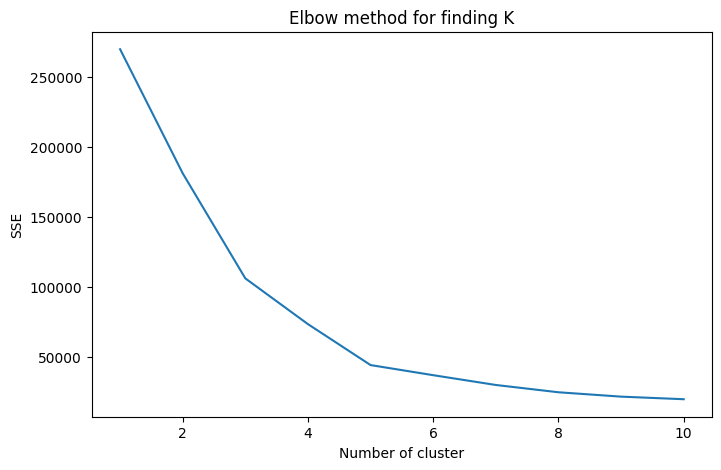

In [6]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11), sse)
plt.title('Elbow method for finding K')
plt.xlabel('Number of cluster')
plt.ylabel('SSE')
plt.show()

In [8]:
kmeans = KMeans(n_clusters=5, init= 'k-means++', max_iter=300, n_init=10, random_state=42)
y_kmeans=kmeans.fit_predict(x)

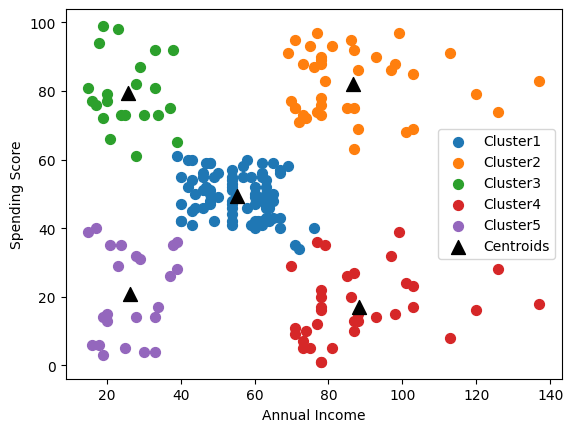

In [13]:
for i in range (5):
    plt.scatter(x[y_kmeans==i,0],x[y_kmeans==i,1], s=50, label = f'Cluster{i+1}')
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], s=100, marker='^', c = 'black', label= 'Centroids')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.legend()
plt.show()